## SETUP

In [1]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_ensemble_multi_backbone
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

2025-09-21 14:57:52.288316: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-21 14:57:52.387500: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-21 14:57:52.405780: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-21 14:57:52.832794: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvi

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_ensemble_dual.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## STARTING POINT

In [10]:
from tensorflow.keras.applications import EfficientNetV2S, MobileNetV2, InceptionV3
from breast_cancer.models.build_ensemble import build_ensemble_dual_backbone

# Build ensemble_resnet model from spec
backbone1 = EfficientNetV2S(**model_cfg["base_model_args"])
backbone2 = MobileNetV2(**model_cfg["base_model_args"])
backbone3 = InceptionV3(**model_cfg["base_model_args"])
backbones = [backbone1, backbone2, backbone3]
backbone_names = [b.name for b in backbones]
backbone_name = "backbones"

# Build model from spec
model = build_ensemble_multi_backbone(*backbones, cfg=model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone_name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

9406464/9406464 [==============================] - 0s 0us/step
Model: "ensemble_multi"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 efficientnetv2-s (Functional)  (None, 8, 8, 1280)   20331360    ['input_4[0][0]']                
                                                                                                  
 mobilenetv2_1.00_224 (Function  (None, 8, 8, 1280)  2257984     ['input_4[0][0]']                
 al)                                                                                              
                      

## MODEL EXPLORATION

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [10]:
from tensorflow.image import grayscale_to_rgb

ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [11]:
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

# Load the model and freeze backbone
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [12]:
# Freeze backbones
for bname in backbone_names:
    backbone = model.get_layer(bname)
    backbone.trainable = False

# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-21 06:59:54.534026: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 06:59:54.560373: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 06:59:54.561136: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 06:59:54.561147: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 06:59:54.561471: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 06:59:54.561513: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 06:59:54.614420: I tensorflow/stream_executor/cuda/c

316/316 [==============================] - 39s 98ms/step - loss: 26.3279 - auc: 0.5752 - binary_accuracy: 0.5661 - precision: 0.4653 - recall: 0.4906 - val_loss: 19.0857 - val_auc: 0.7132 - val_binary_accuracy: 0.6437 - val_precision: 0.5447 - val_recall: 0.6038 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 30s 92ms/step - loss: 14.9977 - auc: 0.5903 - binary_accuracy: 0.5851 - precision: 0.4869 - recall: 0.4867 - val_loss: 11.5014 - val_auc: 0.7005 - val_binary_accuracy: 0.6604 - val_precision: 0.6923 - val_recall: 0.2547 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 30s 92ms/step - loss: 9.2428 - auc: 0.6179 - binary_accuracy: 0.6088 - precision: 0.5168 - recall: 0.4989 - val_loss: 7.2526 - val_auc: 0.6977 - val_binary_accuracy: 0.6493 - val_precision: 0.5583 - val_recall: 0.5425 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 30s 92ms/step - loss: 6.0237 - auc: 0.6189 - binary_accuracy: 0.6145 - precision: 0.52

In [13]:
# Unfreeze parts of the backbone for fine tuning
for bname in backbone_names:
    backbone = model.get_layer(bname)
    backbone_layers = backbone.layers
    start_trainable = -int(0.2*len(backbone_layers))

    for l in backbone_layers[start_trainable:]:
        l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 31s 92ms/step - loss: 0.6782 - auc: 0.6770 - binary_accuracy: 0.6552 - precision: 0.5914 - recall: 0.4760 - val_loss: 0.6872 - val_auc: 0.7092 - val_binary_accuracy: 0.6269 - val_precision: 0.5211 - val_recall: 0.6981 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 30s 92ms/step - loss: 0.6561 - auc: 0.7148 - binary_accuracy: 0.6901 - precision: 0.6427 - recall: 0.5257 - val_loss: 0.7227 - val_auc: 0.7068 - val_binary_accuracy: 0.5989 - val_precision: 0.4958 - val_recall: 0.8396 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 30s 92ms/step - loss: 0.6502 - auc: 0.7132 - binary_accuracy: 0.6861 - precision: 0.6382 - recall: 0.5162 - val_loss: 0.6963 - val_auc: 0.7111 - val_binary_accuracy: 0.6063 - val_precision: 0.5016 - val_recall: 0.7594 - lr: 1.0000e-05
Epoch 4/80
316/316 [==============================] - ETA: 0s - loss: 0.6370 - auc: 0.7441 - binary_accuracy: 0.7045 - precision: 0.6533 - recal

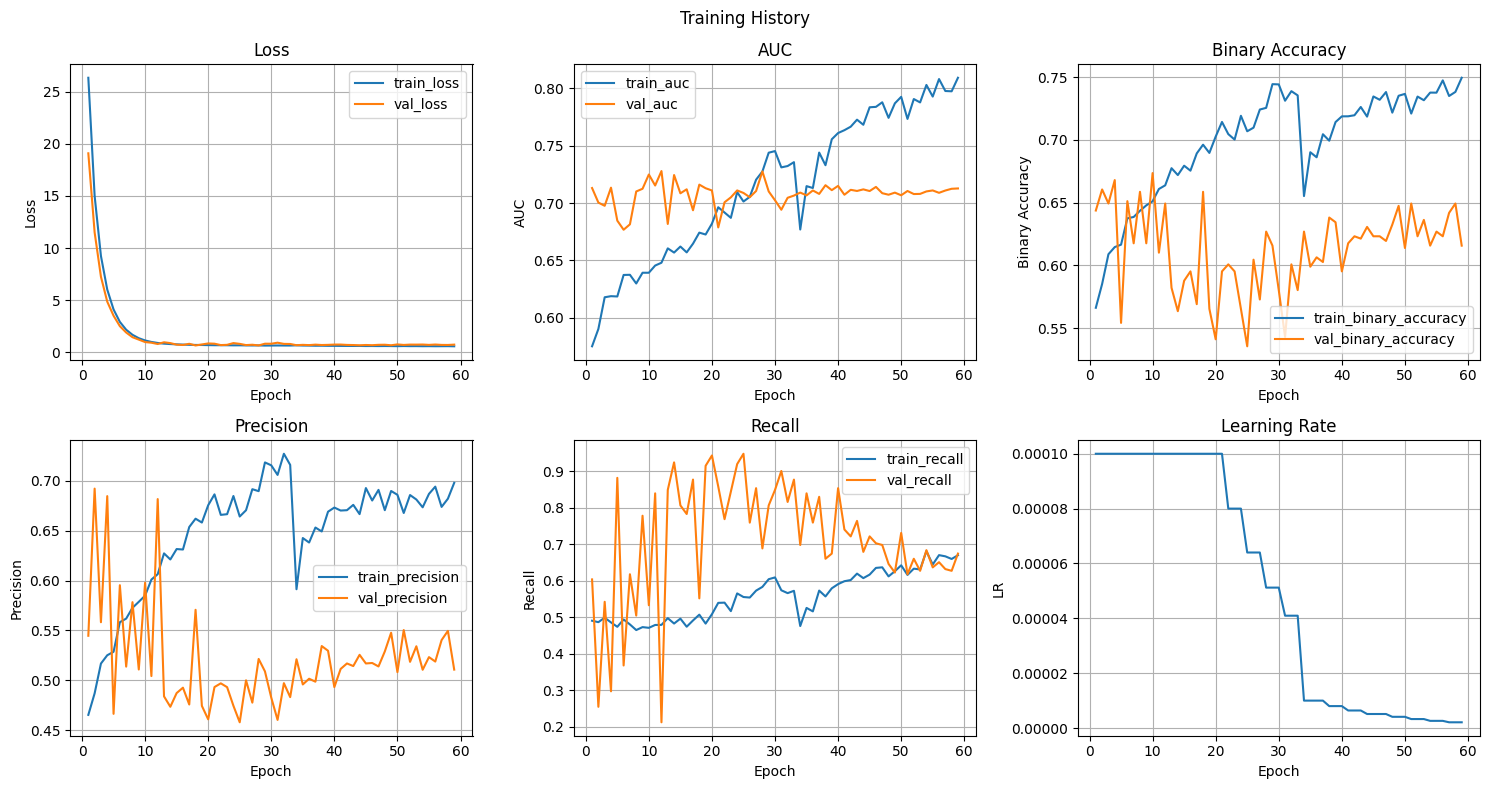

In [14]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2)

plot_history(all_histories)

In [15]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone_name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_multi/initial_ensemble_multi_backbones_image_random.csv'

#### Split by Patient ID

In [16]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [17]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [18]:
# Load the model and freeze backbone
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [19]:
# Freeze backbones
for bname in backbone_names:
    backbone = model.get_layer(bname)
    backbone.trainable = False

# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 38s 98ms/step - loss: 27.7244 - auc_1: 0.5565 - binary_accuracy: 0.5572 - precision_1: 0.4537 - recall_1: 0.4666 - val_loss: 21.3426 - val_auc_1: 0.6471 - val_binary_accuracy: 0.5709 - val_precision_1: 0.4757 - val_recall_1: 0.8302 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 30s 93ms/step - loss: 17.2940 - auc_1: 0.5753 - binary_accuracy: 0.5734 - precision_1: 0.4729 - recall_1: 0.4807 - val_loss: 13.6224 - val_auc_1: 0.7005 - val_binary_accuracy: 0.6511 - val_precision_1: 0.5654 - val_recall_1: 0.5094 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 31s 93ms/step - loss: 11.2213 - auc_1: 0.6032 - binary_accuracy: 0.5953 - precision_1: 0.4995 - recall_1: 0.4818 - val_loss: 9.0116 - val_auc_1: 0.6208 - val_binary_accuracy: 0.5466 - val_precision_1: 0.4563 - val_recall_1: 0.7642 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 31s 93ms/step - loss: 7.4427 - auc_1: 0.6016 - bi

In [20]:
# Unfreeze parts of the backbone for fine tuning
for bname in backbone_names:
    backbone = model.get_layer(bname)
    backbone_layers = backbone.layers
    start_trainable = -int(0.2*len(backbone_layers))

    for l in backbone_layers[start_trainable:]:
        l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


316/316 [==============================] - 30s 93ms/step - loss: 0.6742 - auc_1: 0.7063 - binary_accuracy: 0.6780 - precision_1: 0.6419 - recall_1: 0.4606 - val_loss: 0.7197 - val_auc_1: 0.7365 - val_binary_accuracy: 0.6884 - val_precision_1: 0.6316 - val_recall_1: 0.5094 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 30s 93ms/step - loss: 0.6395 - auc_1: 0.7507 - binary_accuracy: 0.7124 - precision_1: 0.6830 - recall_1: 0.5385 - val_loss: 0.6918 - val_auc_1: 0.7386 - val_binary_accuracy: 0.6810 - val_precision_1: 0.6000 - val_recall_1: 0.5802 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 30s 93ms/step - loss: 0.6195 - auc_1: 0.7708 - binary_accuracy: 0.7273 - precision_1: 0.7049 - recall_1: 0.5596 - val_loss: 0.6967 - val_auc_1: 0.7402 - val_binary_accuracy: 0.6903 - val_precision_1: 0.6095 - val_recall_1: 0.6038 - lr: 1.0000e-05
Epoch 4/80
316/316 [==============================] - 30s 93ms/step - loss: 0.6067 - auc_1: 0.7980 - binary_

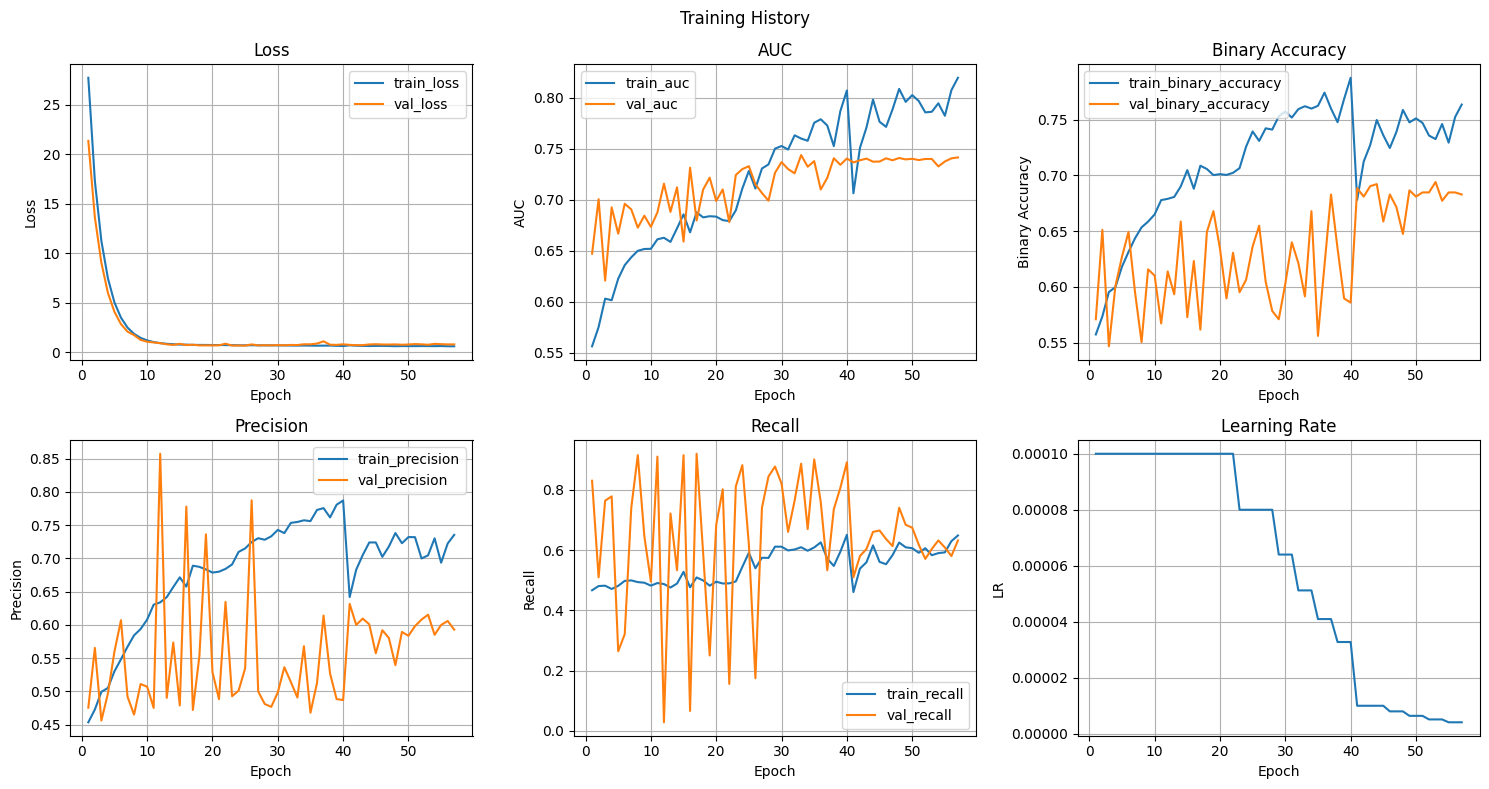

In [21]:
all_histories = append_histories(history_patient1, history_patient2)

plot_history(all_histories)

In [22]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone_name}_patient_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_multi/initial_ensemble_multi_backbones_patient_random.csv'

## FINAL EVALUATION

#### Split by Image ID

In [41]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [42]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [43]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=10, # when model start to overfit during experiments
)

Epoch 1/10


403/403 [==============================] - 48s 93ms/step - loss: 24.4721 - auc_4: 0.6200 - binary_accuracy: 0.5873 - precision_4: 0.4996 - recall_4: 0.5510 - lr: 1.0000e-04
Epoch 2/10
403/403 [==============================] - 38s 93ms/step - loss: 12.3748 - auc_4: 0.6535 - binary_accuracy: 0.6194 - precision_4: 0.5372 - recall_4: 0.5565 - lr: 1.0000e-04
Epoch 3/10
403/403 [==============================] - 38s 93ms/step - loss: 7.0378 - auc_4: 0.6707 - binary_accuracy: 0.6405 - precision_4: 0.5652 - recall_4: 0.5559 - lr: 1.0000e-04
Epoch 4/10
403/403 [==============================] - 38s 93ms/step - loss: 4.3324 - auc_4: 0.6852 - binary_accuracy: 0.6557 - precision_4: 0.5860 - recall_4: 0.5621 - lr: 1.0000e-04
Epoch 5/10
403/403 [==============================] - 37s 93ms/step - loss: 2.8629 - auc_4: 0.6964 - binary_accuracy: 0.6661 - precision_4: 0.5991 - recall_4: 0.5752 - lr: 1.0000e-04
Epoch 6/10
403/403 [==============================] - 38s 93ms/step - loss: 2.0158 - auc_4: 0.

In [44]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone_name}_image_random.h5")

In [45]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone_name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_multi/full_ensemble_multi_backbones_image_random.csv'

In [46]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [47]:
# Final evaluation
model.evaluate(ds_test_image_random)

11/11 [==============================] - 3s 89ms/step - loss: 0.8452 - auc_4: 0.7377 - binary_accuracy: 0.6562 - precision_4: 0.5467 - recall_4: 0.7210


[0.8451936841011047,
 0.7377040386199951,
 0.65625,
 0.5467032790184021,
 0.7210144996643066]

#### Split by Patient ID

In [48]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [49]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [50]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=10, # when model start to overfit during experiments
)

Epoch 1/10


392/392 [==============================] - 49s 93ms/step - loss: 24.7200 - auc_5: 0.6036 - binary_accuracy: 0.5793 - precision_5: 0.4796 - recall_5: 0.5299 - lr: 1.0000e-04
Epoch 2/10
392/392 [==============================] - 36s 92ms/step - loss: 12.7846 - auc_5: 0.6358 - binary_accuracy: 0.6136 - precision_5: 0.5197 - recall_5: 0.5288 - lr: 1.0000e-04
Epoch 3/10
392/392 [==============================] - 37s 93ms/step - loss: 7.3879 - auc_5: 0.6592 - binary_accuracy: 0.6315 - precision_5: 0.5427 - recall_5: 0.5376 - lr: 1.0000e-04
Epoch 4/10
392/392 [==============================] - 36s 92ms/step - loss: 4.5989 - auc_5: 0.6770 - binary_accuracy: 0.6562 - precision_5: 0.5774 - recall_5: 0.5443 - lr: 1.0000e-04
Epoch 5/10
392/392 [==============================] - 36s 92ms/step - loss: 3.0500 - auc_5: 0.6780 - binary_accuracy: 0.6565 - precision_5: 0.5802 - recall_5: 0.5312 - lr: 1.0000e-04
Epoch 6/10
392/392 [==============================] - 36s 92ms/step - loss: 2.1332 - auc_5: 0.

In [51]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone_name}_patient_random.h5")

In [52]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone_name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/ensemble_multi/full_ensemble_multi_backbones_patient_random.csv'

In [53]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [54]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 3s 82ms/step - loss: 1.1621 - auc_5: 0.7605 - binary_accuracy: 0.5674 - precision_5: 0.4977 - recall_5: 0.9703


[1.1621497869491577,
 0.7605196237564087,
 0.5674300193786621,
 0.49771690368652344,
 0.9703264236450195]